In [ ]:
# import data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Found 1123 files belonging to 6 classes.
Using 899 files for training.
Found 1123 files belonging to 6 classes.
Using 224 files for validation.
['bowecho_squall', 'multicell', 'nonradar_image', 'qlcs_squall', 'single_cell', 'supercell']
Number of class: 6


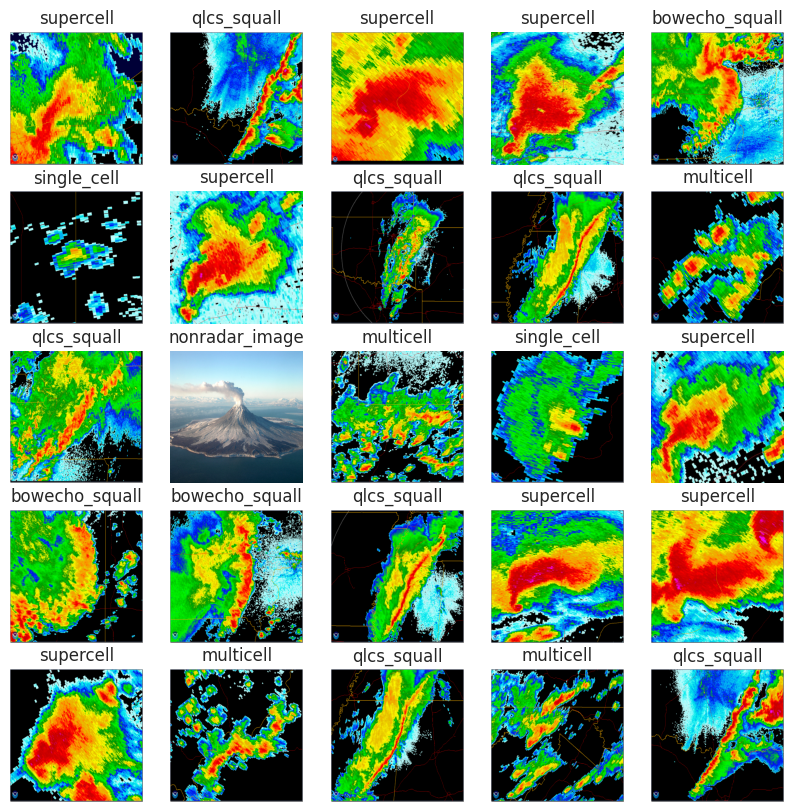

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# neural network imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

# data preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# seabourn theme and sizing for data visualization
sns.set_style("white")
plt.rcParams['figure.figsize'] = (12, 8)

# random seed
np.random.seed(71)
tf.random.set_seed(71)

# load dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory="drive/MyDrive/cell_id_products/train/",
    validation_split=0.2,
    image_size=(512,512),
    seed=71,
    subset="training",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    shuffle=True
)
val_ds = keras.utils.image_dataset_from_directory(
    directory="drive/MyDrive/cell_id_products/train/",
    validation_split=0.2,
    image_size=(512,512),
    seed=71,
    subset="validation",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    shuffle=True
)


# inspecting dataset
class_names = train_ds.class_names
print(class_names)
print("Number of class:", len(class_names))

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
  for i in range(25):
    ax = plt.subplot(5,5,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

  # randomizing backgrounds to prevent model shortcut on black backgrounds

def randomize_background(image, label):
    image = tf.cast(image, tf.float32)

    # Find nearly black background pixels
    background_mask = tf.reduce_all(
        image < 30,
        axis=-1,
        keepdims=True
    )

    # Generate one random background color for the entire image
    background_color = tf.random.uniform(
        shape=(1, 1, 3),
        minval=0,
        maxval=150,
        dtype=tf.float32
    )

    # Replace only background pixels
    image = tf.where(
        background_mask,
        background_color,
        image
    )

    return image, label


# caching

AUTOTUNE = tf.data.AUTOTUNE

# Cache original images
train_ds = train_ds.cache()

# Then randomize the background
train_ds = train_ds.map(
    randomize_background,
    num_parallel_calls=AUTOTUNE
)

# Prefetch final dataset
train_ds = train_ds.prefetch(AUTOTUNE)

# Validation dataset stays normal
val_ds = val_ds.cache().prefetch(AUTOTUNE)



In [ ]:
# model creation
def create_model():

  # build the CNN model
  model = Sequential()
  model.add(layers.Rescaling(1./255, input_shape=(512,512,3)))
  model.add(layers.Conv2D(32, (3, 3), padding="same",activation="relu"))
  model.add(layers.MaxPooling2D((2,2)))
  model.add(layers.Conv2D(64, (3, 3), padding="same",activation="relu"))
  model.add(layers.MaxPooling2D((2,2)))
  model.add(layers.Conv2D(128, (3, 3), padding="same",activation="relu"))
  model.add(layers.MaxPooling2D((2,2)))
  model.add(layers.Conv2D(256, (3, 3), padding="same",activation="relu"))
  model.add(layers.MaxPooling2D((2,2)))
  model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu"))
  model.add(layers.MaxPooling2D((2,2)))
  model.add(layers.GlobalAveragePooling2D())
  model.add(Dense(128, activation="relu"))
  model.add(Dropout(0.2))
  model.add(Dense(6, activation="softmax"))

  # compile
  model.compile(
      optimizer="adam",
      loss="categorical_crossentropy",
      metrics=['accuracy']
  )
  print("Model Compiled Successfully!")
  return model

In [ ]:
model = create_model()
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model Compiled Successfully!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 512, 512, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,635,014 (6.24 MB)

 Trainable params: 1,635,014 (6.24 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
custom_class_weights = {
    0: 1.0, # bow echo
    1: 1.0, # multicell
    2: 1.0, # non radar
    3: 1.0, # qlcs
    4: 1.0, # single cell
    5: 1.0 # supercell
}

# train model
history = model.fit(train_ds, validation_data=val_ds, epochs=30, class_weight=custom_class_weights)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 615ms/step - accuracy: 0.2503 - loss: 1.6496 - val_accuracy: 0.4777 - val_loss: 1.3676
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 386ms/step - accuracy: 0.4316 - loss: 1.3355 - val_accuracy: 0.5179 - val_loss: 1.0682
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 372ms/step - accuracy: 0.5250 - loss: 1.1331 - val_accuracy: 0.6205 - val_loss: 0.9265
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 358ms/step - accuracy: 0.5717 - loss: 1.0548 - val_accuracy: 0.6116 - val_loss: 0.8800
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 360ms/step - accuracy: 0.5884 - loss: 0.9483 - val_accuracy: 0.6652 - val_loss: 0.7821
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.6363 - loss: 0.8540 - val_accuracy: 0.7188 - val_loss: 0.7029
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 374ms/step - accuracy: 0.6874 - loss: 0.7553 - val_accuracy: 0.7500 - val_loss: 0.5792
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 380ms/step - accuracy: 0.7164 - loss: 0.6765 - val_accu

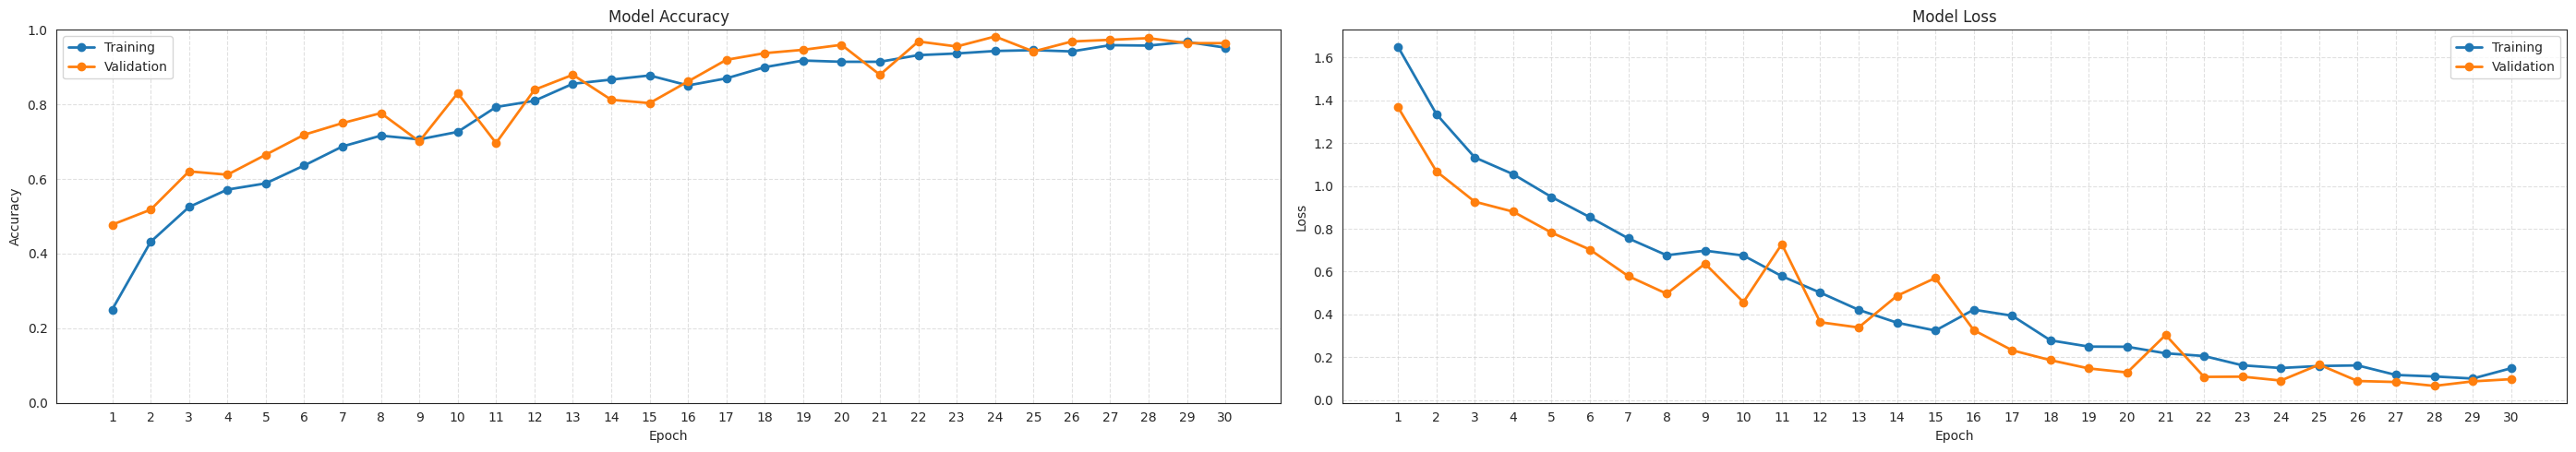

In [ ]:
# Accuracy and Loss Graphs

epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(28, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'],
         marker='o', linewidth=2, label='Training')
plt.plot(epochs, history.history['val_accuracy'],
         marker='o', linewidth=2, label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'],
         marker='o', linewidth=2, label='Training')
plt.plot(epochs, history.history['val_loss'],
         marker='o', linewidth=2, label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

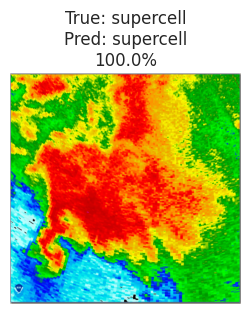

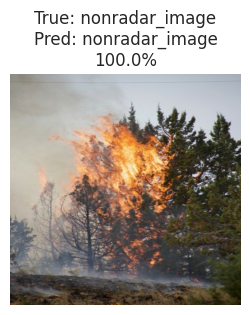

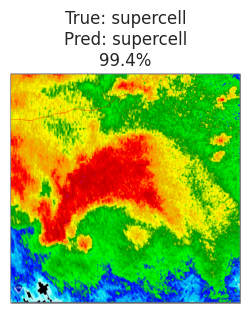

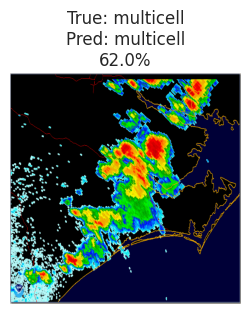

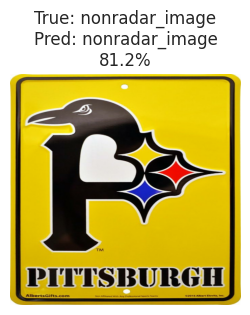

In [ ]:
# Review Validation Expamples
for images, labels in val_ds.take(1):
    for i in range(5):
        prediction = model.predict(
            np.expand_dims(images[i], axis=0),
            verbose=0
        )

        pred = np.argmax(prediction)
        true = np.argmax(labels[i])

        plt.figure(figsize=(3,3))
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(
            f"True: {class_names[true]}\n"
            f"Pred: {class_names[pred]}\n"
            f"{np.max(prediction):.1%}"
        )
        plt.show()

In [ ]:
# save model and review details
import os

model.save('/content/drive/MyDrive/models/project_cell_id_model.keras')